# 01 · EDA inicial — Demanda eléctrica horaria del MEM

**Proyecto:** Forecast de demanda eléctrica del Mercado Eléctrico Mayorista (MEM) argentino.
**Etapa:** Pre-entrega 1 — estructura del repo, datos y primera mirada.

## Objetivo de este notebook

Antes de modelar hay que conocer el dato. Acá respondemos:

1. **Volumen y granularidad:** ¿cuántas filas, qué período, cada cuánto tiempo hay una medición?
2. **Calidad:** ¿hay huecos en la serie, duplicados, faltantes, ceros sospechosos?
3. **Estructura temporal:** ¿cómo es la curva diaria, semanal y anual? Esto es lo que después el modelo tiene que aprender.

## Fuente

CAMMESA publica en su sitio (Informes y Estadísticas) dos planillas oficiales con la demanda real neta del MEM en paso horario:

| Planilla | Alcance | Período |
|---|---|---|
| "Demanda Horaria por Tipo" | Total país, dividido en Distribuidores y Grandes Usuarios | ene-2023 → jul-2026 |
| "Demanda Horaria por Regiones" | Total país + 9 regiones | ene-2021 → dic-2023 |

En el año en que se solapan (2023) las dos coinciden hora a hora (diferencia máxima 0,04 %), así que las encadenamos: regiones para 2021–2022, por tipo desde 2023. El script `src/descargar_demanda_mem.py` hace la descarga y el armado; este notebook trabaja sobre su salida `data/processed/demanda_horaria_mem.csv`.

**Decisión de alcance:** se trabaja con el **total país (MEM)**, 2021 → jul-2026. Es la serie que CAMMESA efectivamente pronostica para programar el despacho, y da 5 ciclos estacionales completos. La desagregación regional (solo 2021–2023) se usa al final como análisis complementario.

**Unidad:** MWh por hora. Como el intervalo es de una hora, el valor coincide numéricamente con la potencia media en MW de esa hora.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = BASE / "data" / "processed"
FIG = BASE / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIG / f"01_{nombre}.png", bbox_inches="tight")
    plt.show()

## 1. Carga y estructura del dataset

In [2]:
df = pd.read_csv(DATA / "demanda_horaria_mem.csv", parse_dates=["timestamp"])
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 48912 entries, 0 to 48911
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         48912 non-null  datetime64[us]
 1   demanda_mwh       48912 non-null  float64       
 2   demanda_dist_mwh  31392 non-null  float64       
 3   demanda_gu_mwh    31392 non-null  float64       
 4   tipo_dia          48912 non-null  str           
 5   fuente            48912 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 3.4 MB


,timestamp,demanda_mwh,demanda_dist_mwh,demanda_gu_mwh,tipo_dia,fuente
0,2021-01-01 00:00:00,12329.594,NaN,NaN,no_habil,regiones_2021_2023
1,2021-01-01 01:00:00,12097.918,NaN,NaN,no_habil,regiones_2021_2023
2,2021-01-01 02:00:00,11805.739,NaN,NaN,no_habil,regiones_2021_2023
3,2021-01-01 03:00:00,11447.416,NaN,NaN,no_habil,regiones_2021_2023
4,2021-01-01 04:00:00,11143.879,NaN,NaN,no_habil,regiones_2021_2023


Columnas:

- `timestamp`: inicio de la hora (hora local, UTC-3). CAMMESA numera las horas 1..24; la hora *h* es el intervalo (h-1):00 → h:00. En el script ya se convirtió a `timestamp = fecha + (h-1) horas`.
- `demanda_mwh`: demanda real neta total del MEM en esa hora. **Es la variable objetivo.**
- `demanda_dist_mwh` / `demanda_gu_mwh`: desagregación en Distribuidores (residencial + comercial + pequeña industria, vía EDENOR, EDESUR, EPEC, etc.) y Grandes Usuarios del MEM (industrias que compran directo en el mercado). Solo disponible desde 2023 — por eso tiene nulos en 2021–2022.
- `tipo_dia`: clasificación propia de CAMMESA (`habil` / `no_habil`). `no_habil` incluye sábados, domingos y feriados. Nos ahorra construir un calendario de feriados a mano y, además, refleja el criterio que usa el operador.
- `fuente`: de qué planilla salió cada fila (trazabilidad).

In [3]:
print(f"Filas: {len(df):,}")
print(f"Rango: {df.timestamp.min()}  ->  {df.timestamp.max()}")
print(f"Duración: {(df.timestamp.max() - df.timestamp.min()).days / 365.25:.2f} años")
print()
print(df["fuente"].value_counts().rename("horas por fuente"))

Filas: 48,912
Rango: 2021-01-01 00:00:00  ->  2026-07-31 23:00:00
Duración: 5.58 años

fuente
por_tipo_2023_2026    31392
regiones_2021_2023    17520
Name: horas por fuente, dtype: int64


## 2. Granularidad y huecos

Para una serie temporal el primer chequeo es si el índice de tiempo es **regular**: si entre cada fila y la siguiente pasa siempre lo mismo. Si hubiera huecos (horas que faltan) los lags y las ventanas móviles que usemos más adelante quedarían corridos sin que nos demos cuenta.

Comparamos la cantidad de horas que *hay* con las que *debería haber* entre el primer y el último timestamp.

In [4]:
# Diferencia entre timestamps consecutivos: si todo es 1 h, la serie es regular
deltas = df["timestamp"].diff().dropna().value_counts()
print("Distribución de saltos entre filas consecutivas:")
print(deltas)

esperadas = pd.date_range(df.timestamp.min(), df.timestamp.max(), freq="h")
faltantes = esperadas.difference(df["timestamp"])
print(f"\nHoras esperadas: {len(esperadas):,} | Horas presentes: {df.timestamp.nunique():,} | Faltantes: {len(faltantes)}")
print(f"Timestamps duplicados: {df.timestamp.duplicated().sum()}")

Distribución de saltos entre filas consecutivas:
timestamp
0 days 01:00:00    48911
Name: count, dtype: int64

Horas esperadas: 48,912 | Horas presentes: 48,912 | Faltantes: 0
Timestamps duplicados: 0


In [5]:
# Chequeo por año: cada año debe tener 8760 h (8784 si es bisiesto); 2026 está incompleto
horas_por_anio = df.groupby(df.timestamp.dt.year).size().rename("horas")
esperado = pd.Series({a: 8784 if pd.Timestamp(year=a, month=1, day=1).is_leap_year else 8760 for a in horas_por_anio.index}, name="esperadas")
pd.concat([horas_por_anio, esperado], axis=1).assign(diferencia=lambda d: d.horas - d.esperadas)

,horas,esperadas,diferencia
2021,8760,8760,0
2022,8760,8760,0
2023,8760,8760,0
2024,8784,8784,0
2025,8760,8760,0
2026,5088,8760,-3672


**Resultado:** la serie es perfectamente regular — 48.912 horas consecutivas sin un solo hueco ni duplicado. 2024 tiene 8.784 horas por ser bisiesto y 2026 está incompleto porque termina en julio (CAMMESA publica cada mes ~2 semanas después de cerrado).

Esto simplifica mucho la Pre-entrega 2: no hay que imputar horas faltantes. Ayuda también que Argentina no aplica horario de verano desde 2009, así que no hay días de 23 o 25 horas.

## 3. Faltantes, ceros y distribución de la variable objetivo

In [6]:
nulos = df.isna().sum().to_frame("nulos")
nulos["pct"] = (nulos["nulos"] / len(df) * 100).round(1)
nulos

,nulos,pct
timestamp,0,0.0
demanda_mwh,0,0.0
demanda_dist_mwh,17520,35.8
demanda_gu_mwh,17520,35.8
tipo_dia,0,0.0
fuente,0,0.0


In [7]:
print("Ceros o negativos en demanda_mwh:", (df["demanda_mwh"] <= 0).sum())
df["demanda_mwh"].describe().round(0)

Ceros o negativos en demanda_mwh: 0


count    48912.0
mean     15953.0
std       2866.0
min       9282.0
25%      13879.0
50%      15629.0
75%      17725.0
max      28094.0
Name: demanda_mwh, dtype: float64

Los únicos nulos están en la desagregación Distribuidores / Grandes Usuarios, y son *estructurales* (esa apertura recién existe desde 2023), no datos perdidos. La variable objetivo no tiene ni un nulo ni un cero.

Rango de la demanda: de ~9.300 MW (madrugada de un domingo templado) a ~28.100 MW (tarde de una ola de calor), con media ~16.000 MW. Esa amplitud de 3× es lo que hace valioso el pronóstico: el operador tiene que tener lista generación para cubrir el pico, y cuanto mejor lo anticipe menos reserva "por las dudas" mantiene encendida.

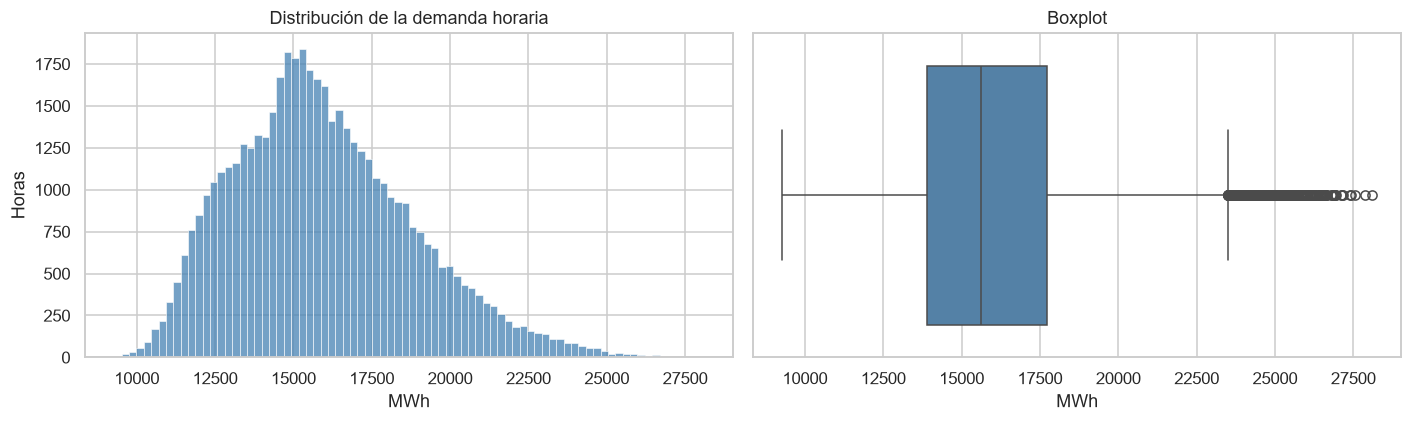

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["demanda_mwh"], bins=80, ax=ax[0], color="steelblue")
ax[0].set(title="Distribución de la demanda horaria", xlabel="MWh", ylabel="Horas")
sns.boxplot(x=df["demanda_mwh"], ax=ax[1], color="steelblue")
ax[1].set(title="Boxplot", xlabel="MWh")
guardar("distribucion_demanda")

La distribución es unimodal y algo asimétrica a la derecha (cola de picos de calor). Los puntos que el boxplot marca como "outliers" (por encima de ~23.500 MW, el límite Q3 + 1,5·IQR) son horas de olas de calor reales, no errores de medición — esto lo vamos a confirmar al cruzar con temperatura en la Pre-entrega 2. Conviene no eliminarlos: son precisamente las horas que más le importa acertar al operador.

## 4. Serie completa y tendencia interanual

Graficar 49.000 puntos horarios es ilegible, así que agregamos a **media diaria** y superponemos una **media móvil de 30 días** para ver la tendencia.

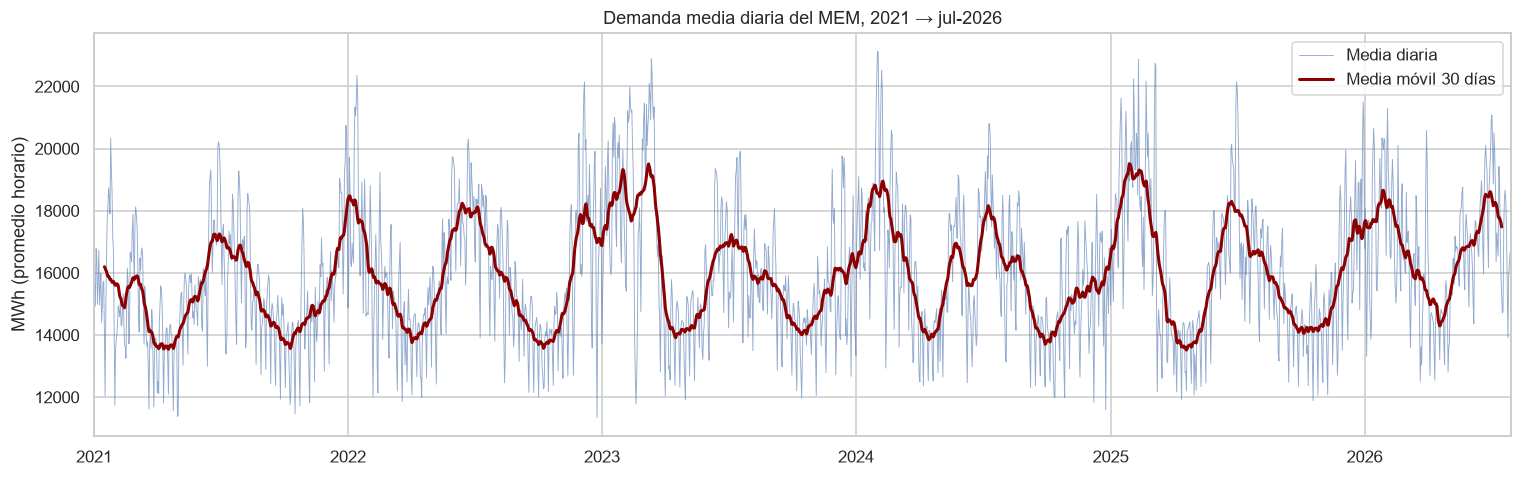

In [9]:
diario = df.set_index("timestamp")["demanda_mwh"].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
diario.plot(ax=ax, lw=0.6, alpha=0.6, label="Media diaria")
diario.rolling(30, center=True).mean().plot(ax=ax, lw=2, color="darkred", label="Media móvil 30 días")
ax.set(title="Demanda media diaria del MEM, 2021 → jul-2026", ylabel="MWh (promedio horario)", xlabel="")
ax.legend()
guardar("serie_diaria")

In [10]:
anual = df.groupby(df.timestamp.dt.year)["demanda_mwh"].agg(media="mean", maximo="max", minimo="min").round(0)
anual["var_media_%"] = anual["media"].pct_change().mul(100).round(1)
anual

,media,maximo,minimo,var_media_%
timestamp,,,,
2021,15283.0,25092.0,9530.0,NaN
2022,15842.0,26213.0,9282.0,3.7
2023,16083.0,26918.0,9626.0,1.5
2024,15963.0,27433.0,9377.0,-0.7
2025,16125.0,28094.0,9638.0,1.0
2026,16764.0,25884.0,10428.0,4.0


Se ven dos cosas que el modelo va a tener que manejar:

- **Estacionalidad anual doble:** hay un pico en verano (ene–feb, aire acondicionado) y otro en invierno (jun–jul, calefacción). Es la relación en forma de U con la temperatura que describimos en el planteo del proyecto.
- **Tendencia leve:** la media anual sube o baja unos pocos puntos porcentuales según el año (actividad económica, clima del año). No es un crecimiento sostenido fuerte, pero un modelo entrenado en 2021 y evaluado en 2026 tiene que tolerar ese corrimiento. *(Ojo: la fila de 2026 solo cubre ene–jul, no es comparable con años completos.)*

## 5. Estacionalidad anual: distribución por mes

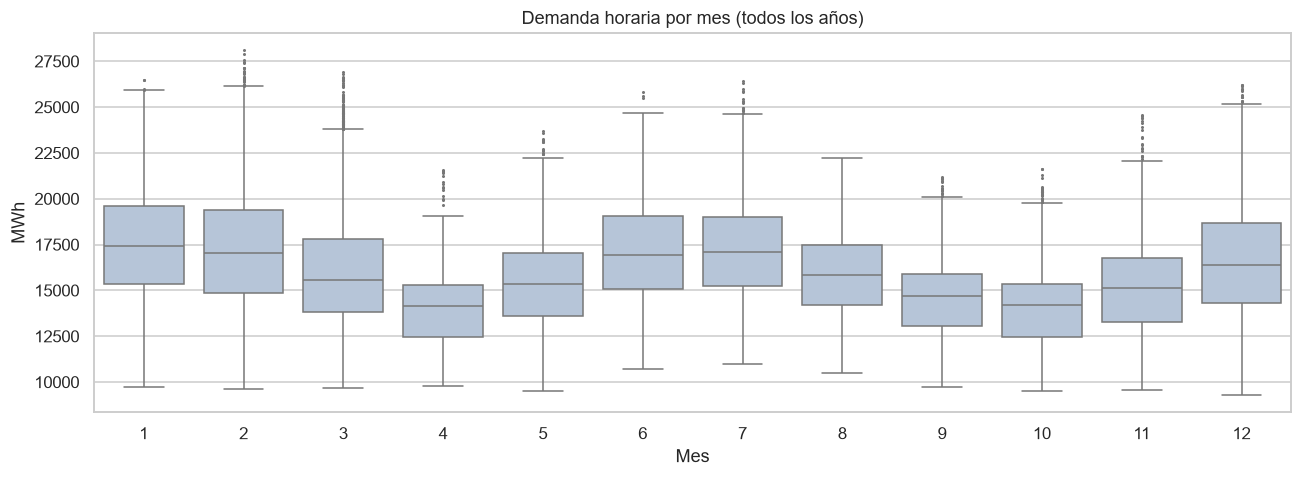

In [11]:
df["anio"] = df.timestamp.dt.year
df["mes"] = df.timestamp.dt.month
df["hora"] = df.timestamp.dt.hour
df["dia_semana"] = df.timestamp.dt.dayofweek  # 0 = lunes

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.boxplot(data=df, x="mes", y="demanda_mwh", ax=ax, color="lightsteelblue", fliersize=1)
ax.set(title="Demanda horaria por mes (todos los años)", xlabel="Mes", ylabel="MWh")
guardar("boxplot_mes")

La forma de "W" invertida confirma los dos picos: **enero–febrero** (calor) y **junio–julio** (frío). Los meses de transición (abril, octubre) son los más bajos y con menos dispersión: temperatura confortable, ni calefacción ni refrigeración. Enero es además el mes con la cola alta más larga — ahí están las horas récord.

## 6. Curva diaria típica

La "curva de carga" es la firma más importante de la demanda eléctrica. La vemos separando días hábiles de no hábiles, porque el uso comercial e industrial cambia completamente la forma.

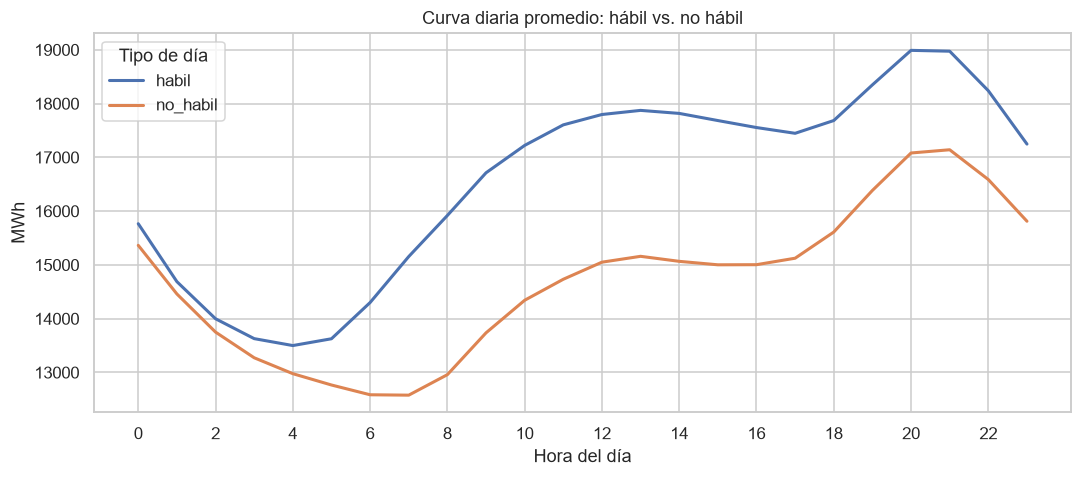

In [12]:
curva = df.groupby(["tipo_dia", "hora"])["demanda_mwh"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(10, 4.5))
curva.plot(ax=ax, lw=2)
ax.set(title="Curva diaria promedio: hábil vs. no hábil", xlabel="Hora del día", ylabel="MWh", xticks=range(0, 24, 2))
ax.legend(title="Tipo de día")
guardar("curva_diaria_tipo_dia")

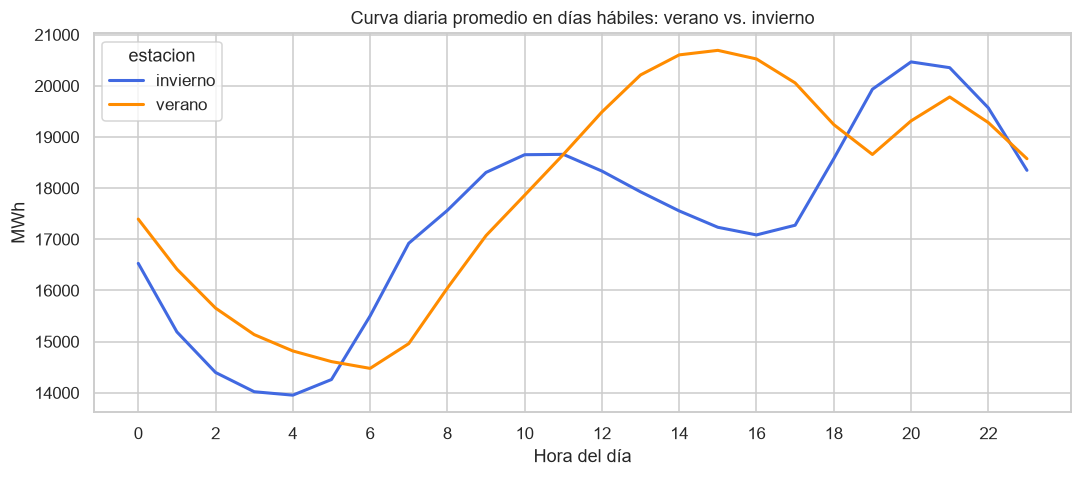

In [13]:
# La misma curva pero separando verano e invierno: cambia la hora del pico
estacion = df["mes"].map({12: "verano", 1: "verano", 2: "verano", 6: "invierno", 7: "invierno", 8: "invierno"})
sub = df[estacion.notna() & (df["tipo_dia"] == "habil")].assign(estacion=estacion)
curva_est = sub.groupby(["estacion", "hora"])["demanda_mwh"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(10, 4.5))
curva_est.plot(ax=ax, lw=2, color={"verano": "darkorange", "invierno": "royalblue"})
ax.set(title="Curva diaria promedio en días hábiles: verano vs. invierno", xlabel="Hora del día", ylabel="MWh", xticks=range(0, 24, 2))
guardar("curva_diaria_estacion")

Lecturas:

- **Valle nocturno** entre las 3 y las 6 h; **rampa de subida** fuerte de 6 a 10 h cuando arranca la actividad.
- En días hábiles la demanda se mantiene alta toda la jornada laboral; en no hábiles la curva es más chata y el nivel cae ~10–15 %.
- **El pico cambia de hora según la estación:** en verano el máximo es a la tarde (14–16 h, calor + oficinas + aire acondicionado); en invierno la curva tiene dos jorobas, una a media mañana (10–11 h) y el máximo a la noche (20–21 h, iluminación + calefacción al llegar a casa), con un valle a la siesta. Esto es una interacción *hora × estación* que un modelo lineal simple no captura y justifica probar Random Forest.

## 7. Perfil semanal

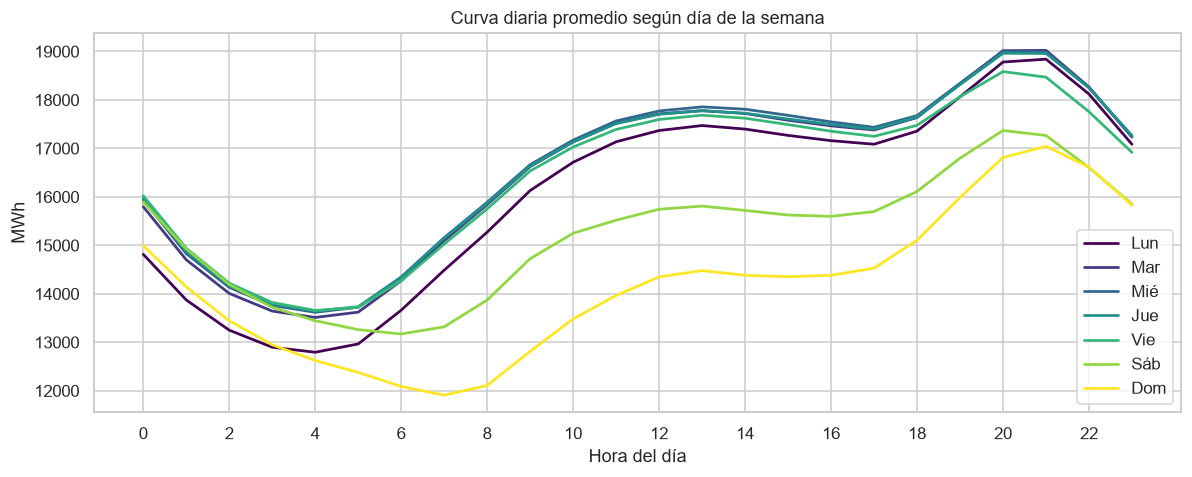

In [14]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
semanal = df.groupby(["dia_semana", "hora"])["demanda_mwh"].mean().unstack(0)
semanal.columns = dias

fig, ax = plt.subplots(figsize=(11, 4.5))
semanal.plot(ax=ax, lw=1.8, cmap="viridis")
ax.set(title="Curva diaria promedio según día de la semana", xlabel="Hora del día", ylabel="MWh", xticks=range(0, 24, 2))
guardar("perfil_semanal")

Martes a viernes son prácticamente indistinguibles. El lunes arranca algo más bajo en la madrugada (arrastra el domingo). El sábado es intermedio (comercio abierto a la mañana, industria parada) y el domingo es el día más bajo. Esto sugiere que como variable de calendario alcanza con algo como *hábil / sábado / domingo-feriado* más que con los 7 días por separado — lo evaluamos en la Pre-entrega 2.

## 8. Mapa de calor hora × mes

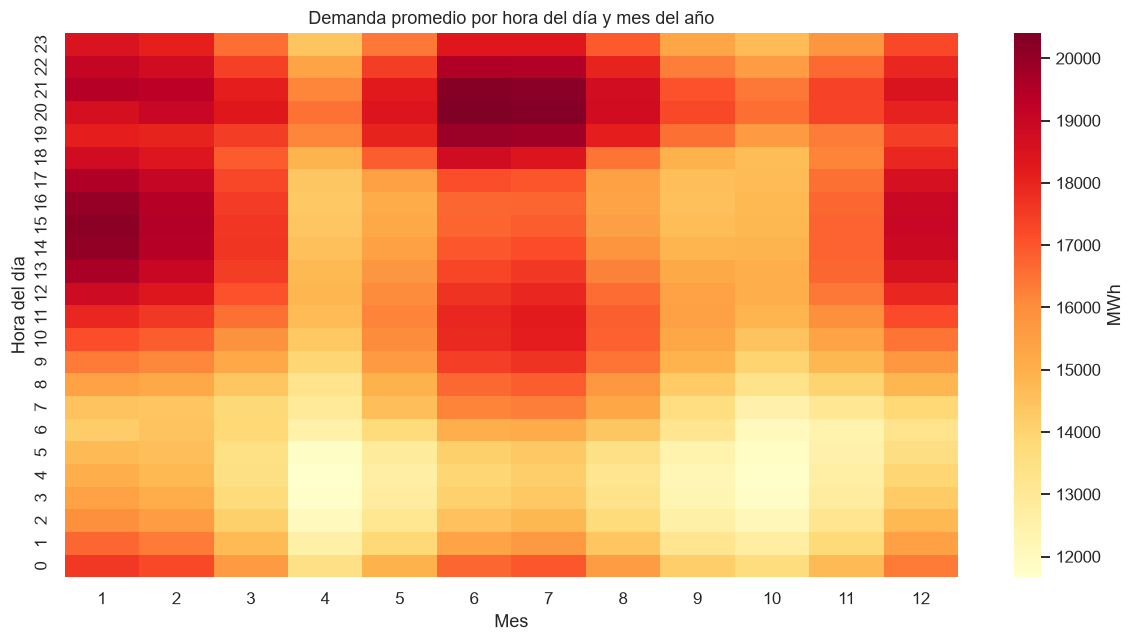

In [15]:
mapa = df.pivot_table(index="hora", columns="mes", values="demanda_mwh", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(mapa, cmap="YlOrRd", ax=ax, cbar_kws={"label": "MWh"})
ax.set(title="Demanda promedio por hora del día y mes del año", xlabel="Mes", ylabel="Hora del día")
ax.invert_yaxis()
guardar("heatmap_hora_mes")

El mapa resume todo lo anterior en una imagen: dos "manchas" calientes, una a la tarde de enero–febrero y otra a la noche de junio–julio, y una banda fría de madrugada todo el año. Cuando presentemos el modelo, esta es la figura que explica por qué hora y mes (o temperatura) son las variables que más pesan.

## 9. Las horas de mayor demanda

In [16]:
top = df.nlargest(10, "demanda_mwh")[["timestamp", "demanda_mwh", "tipo_dia"]].reset_index(drop=True)
top["demanda_mwh"] = top["demanda_mwh"].round(0)
top

,timestamp,demanda_mwh,tipo_dia
0,2025-02-10 15:00:00,28094.0,habil
1,2025-02-10 14:00:00,27884.0,habil
2,2025-02-10 16:00:00,27550.0,habil
3,2024-02-01 14:00:00,27433.0,habil
4,2024-02-01 15:00:00,27388.0,habil
5,2024-02-02 14:00:00,27158.0,habil
6,2024-02-02 15:00:00,27137.0,habil
7,2025-02-10 13:00:00,27118.0,habil
8,2025-02-10 17:00:00,26956.0,habil
9,2025-02-21 15:00:00,26923.0,habil


Todos los máximos históricos de la serie caen en tardes de días hábiles de verano. Son los eventos que más le importan al operador (riesgo de cortes) y también los más difíciles de pronosticar, porque dependen de olas de calor.

## 10. Complemento: desagregación regional (2021–2023)

La planilla por regiones solo llega a 2023, por eso no es la base del modelo. Pero sirve para entender qué hay "adentro" del total país.

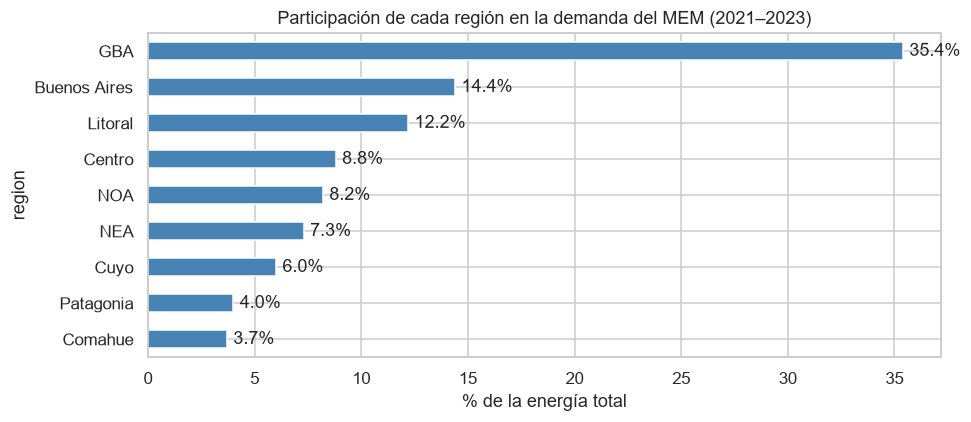

In [17]:
reg = pd.read_csv(DATA / "demanda_horaria_regiones_2021_2023.csv", parse_dates=["timestamp"])
participacion = reg.groupby("region")["demanda_mwh"].sum()
participacion = (participacion / participacion.sum() * 100).sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
participacion.plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set(title="Participación de cada región en la demanda del MEM (2021–2023)", xlabel="% de la energía total")
for i, v in enumerate(participacion):
    ax.text(v + 0.3, i, f"{v}%", va="center")
guardar("participacion_regional")

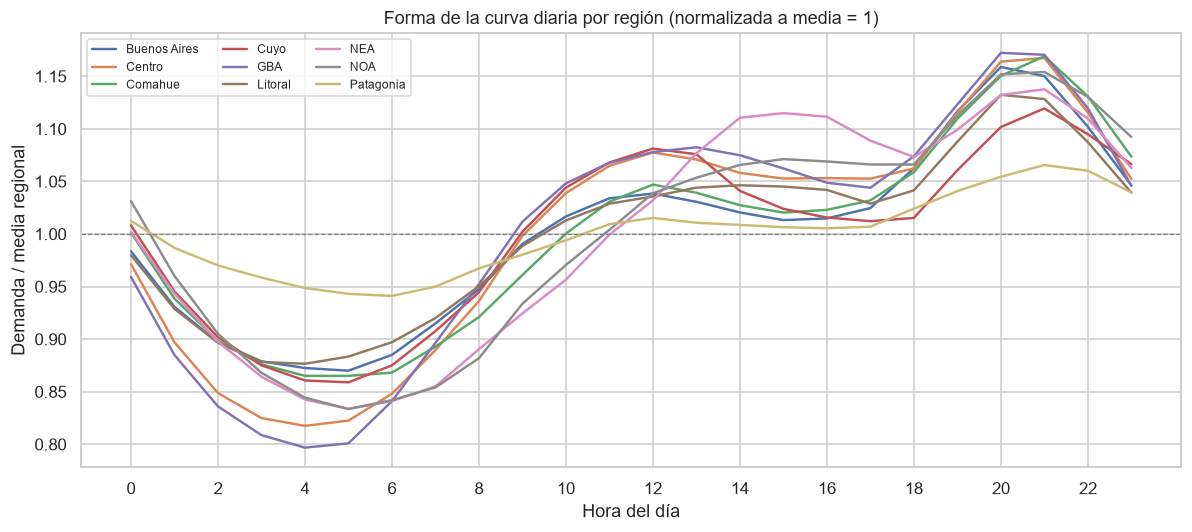

In [18]:
# Curva diaria de cada región normalizada por su propia media, para comparar formas y no tamaños
reg["hora"] = reg.timestamp.dt.hour
curva_reg = reg.groupby(["region", "hora"])["demanda_mwh"].mean().unstack(0)
curva_reg_norm = curva_reg / curva_reg.mean()

fig, ax = plt.subplots(figsize=(11, 5))
curva_reg_norm.plot(ax=ax, lw=1.6)
ax.axhline(1, color="gray", ls="--", lw=0.8)
ax.set(title="Forma de la curva diaria por región (normalizada a media = 1)", xlabel="Hora del día", ylabel="Demanda / media regional", xticks=range(0, 24, 2))
ax.legend(ncol=3, fontsize=8)
guardar("curva_diaria_regional")

GBA + Buenos Aires + Litoral concentran el 62 % de la demanda nacional (GBA sola, 35 %), así que el total país está fuertemente influido por el clima de la región pampeana. Esto es importante para la Pre-entrega 2: al traer temperatura, tiene sentido usar una estación de Buenos Aires (o un promedio ponderado de pocas ciudades) como variable climática del total.

Las curvas normalizadas muestran que Patagonia tiene la curva más chata de todas (oscila apenas ±6 % alrededor de su media): allí pesa la industria petrolera y minera, que consume parejo las 24 h. En el otro extremo, GBA tiene el valle nocturno más profundo (−20 %) y el pico nocturno más alto: perfil residencial puro. NEA se distingue porque su pico es a la tarde (14–16 h) todo el año, por el peso del aire acondicionado en el clima subtropical.

## 11. Hallazgos y decisiones para la siguiente etapa

**Sobre el dato**

- 48.912 horas consecutivas (2021-01-01 → 2026-07-31), sin huecos, duplicados, nulos ni ceros en la variable objetivo. Granularidad horaria confirmada.
- Fuente oficial (CAMMESA), con el tipo de día (hábil / no hábil) ya clasificado por el operador.
- Los valores extremos (> ~23.500 MW según el criterio del boxplot) son olas de calor reales; se conservan.

**Sobre la estructura de la demanda**

- Tres estacionalidades superpuestas: diaria (valle 3–6 h, pico tarde o noche), semanal (hábil > sábado > domingo) y anual (picos en verano e invierno).
- La hora del pico depende de la estación → interacción hora × temporada, argumento para modelos no lineales.
- Tendencia interanual leve pero presente; hay que tenerla en cuenta al hacer el split temporal.

**Decisiones tomadas en esta pre-entrega**

- Alcance: total país (MEM), 2021 → jul-2026.
- Los datos de 5 minutos por región de 2026 (API de CAMMESA) y las observaciones del SMN que ya estaban descargados se conservan en `data/raw/` como material complementario, pero no son la base del modelo.

**Pendiente para la Pre-entrega 2**

- Traer temperatura horaria histórica (Open-Meteo, 2021 → 2026) para Buenos Aires y evaluar si conviene un promedio ponderado de varias ciudades.
- Construir variables de calendario (hora, día de semana, mes, estación, feriado) y variables derivadas de temperatura (grados-día de calefacción y refrigeración).
- Evaluar el tratamiento de la tendencia interanual.